# PS-MNIST Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the PS-MNIST dataset.

**Objectives:**
- Compare S4 vs LMU performance across different data sizes
- Analyze data efficiency (which model learns better with less data)
- Visualize learning curves
- Use **test set metrics** for final evaluation
- Identify the best model/fraction combination

**Fractions tested:** 10%, 25%, 50%, 100%


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Get project root
project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")


Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4


## Load Test Results

Load test_results.json from each run folder for both S4 and LMU models across all data fractions.


In [18]:
runs_dir = Path.cwd() / "runs"

models = ["s4", "lmu"]
fractions = [0.1, 0.25, 0.5, 1.0]

results = []

for model in models:
    for fraction in fractions:
        run_name = f"psmnist_{model}_task"

        if fraction < 1.0:
            run_name += f"_frac_{fraction}"

        test_results_path = runs_dir / run_name / "test_results.json"

        if test_results_path.exists():
            with open(test_results_path, 'r') as f:
                test_data = json.load(f)

            results.append({
                'model': model.upper(),
                'fraction': fraction,
                'loss': test_data.get('loss'),
                'accuracy': test_data.get('accuracy'),
                'run_name': run_name
            })
            print(f"Loaded {run_name}")
        else:
            print(f"Missing {run_name}")

# Create DataFrame
df_results = pd.DataFrame(results)
print(f"\nLoaded {len(df_results)} results")
df_results

Loaded psmnist_s4_task_frac_0.1
Loaded psmnist_s4_task_frac_0.25
Loaded psmnist_s4_task_frac_0.5
Loaded psmnist_s4_task
Loaded psmnist_lmu_task_frac_0.1
Loaded psmnist_lmu_task_frac_0.25
Loaded psmnist_lmu_task_frac_0.5
Loaded psmnist_lmu_task

Loaded 8 results


,model,fraction,loss,accuracy,run_name
0,S4,0.10,0.762207,0.7411,psmnist_s4_task_frac_0.1
1,S4,0.25,0.408691,0.8758,psmnist_s4_task_frac_0.25
2,S4,0.50,0.276855,0.9200,psmnist_s4_task_frac_0.5
3,S4,1.00,0.282227,0.9166,psmnist_s4_task
4,LMU,0.10,0.298645,0.9154,psmnist_lmu_task_frac_0.1
5,LMU,0.25,0.214202,0.9414,psmnist_lmu_task_frac_0.25
6,LMU,0.50,0.181066,0.9475,psmnist_lmu_task_frac_0.5
7,LMU,1.00,0.149894,0.9624,psmnist_lmu_task


## Results Summary Table


In [19]:
pivot_acc = df_results.pivot(index='fraction', columns='model', values='accuracy')
pivot_loss = df_results.pivot(index='fraction', columns='model', values='loss')

print("Test Accuracy by Model and Data Fraction:")
print(pivot_acc)
print("\nTest Loss by Model and Data Fraction:")
print(pivot_loss)

# Calculate improvement
if 'S4' in pivot_acc.columns and 'LMU' in pivot_acc.columns:
    pivot_acc['LMU_vs_S4'] = ((pivot_acc['LMU'] - pivot_acc['S4']) * 100).round(2)
    print("\nLMU vs S4 Accuracy Difference (percentage points):")
    print(pivot_acc['LMU_vs_S4'])

Test Accuracy by Model and Data Fraction:
model        LMU      S4
fraction                
0.10      0.9154  0.7411
0.25      0.9414  0.8758
0.50      0.9475  0.9200
1.00      0.9624  0.9166

Test Loss by Model and Data Fraction:
model          LMU        S4
fraction                    
0.10      0.298645  0.762207
0.25      0.214202  0.408691
0.50      0.181066  0.276855
1.00      0.149894  0.282227

LMU vs S4 Accuracy Difference (percentage points):
fraction
0.10    17.43
0.25     6.56
0.50     2.75
1.00     4.58
Name: LMU_vs_S4, dtype: float64


## Visualization: Test Accuracy Comparison

Compare test accuracy of S4 and LMU across different data fractions.


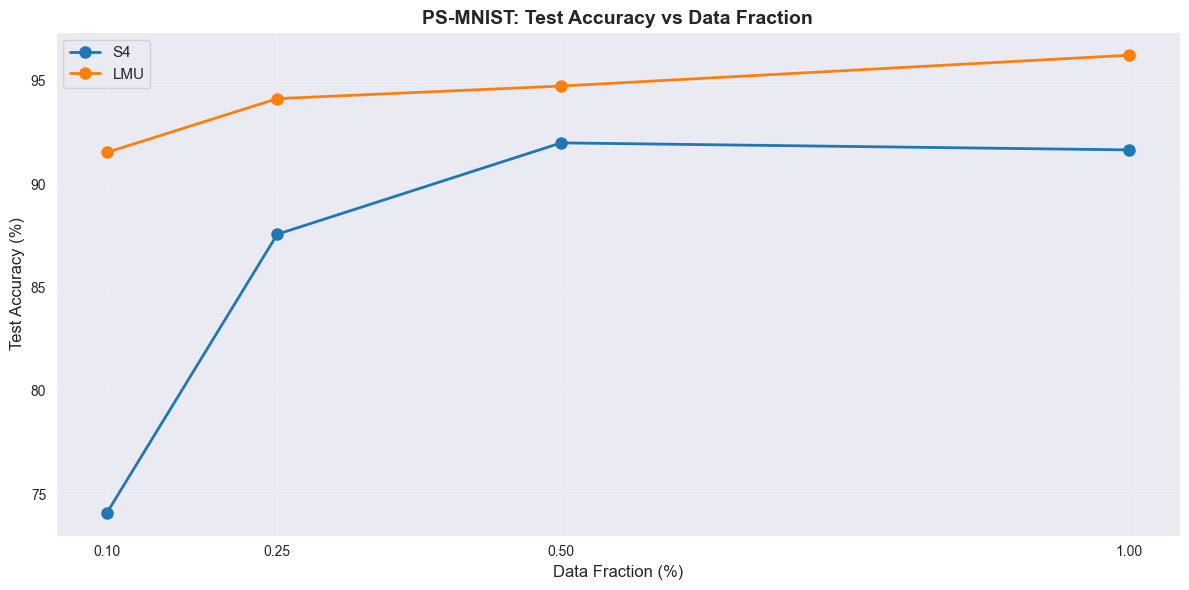

In [20]:
plt.figure(figsize=(12, 6))

for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model]
    plt.plot(model_data['fraction'], model_data['accuracy'] * 100,
             marker='o', linewidth=2, markersize=8, label=model)

plt.xlabel('Data Fraction (%)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('PS-MNIST: Test Accuracy vs Data Fraction', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(fractions)
plt.tight_layout()
plt.show()

## Visualization: Test Loss Comparison

Compare test loss of S4 and LMU across different data fractions.


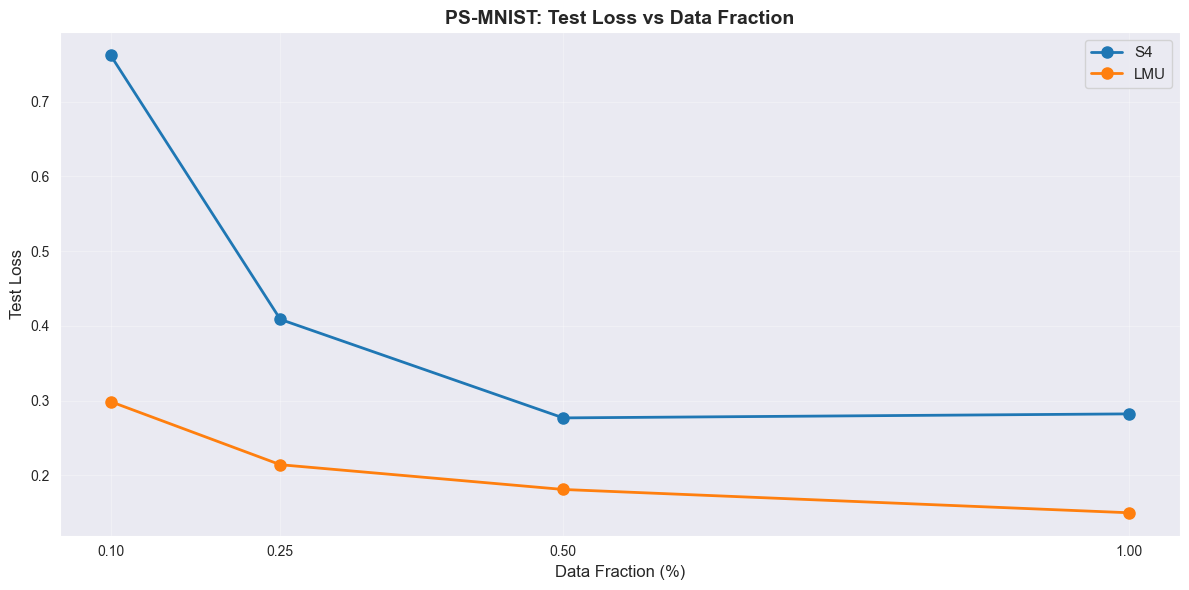

In [21]:
plt.figure(figsize=(12, 6))

for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model]
    plt.plot(model_data['fraction'], model_data['loss'],
             marker='o', linewidth=2, markersize=8, label=model)

plt.xlabel('Data Fraction (%)', fontsize=12)
plt.ylabel('Test Loss', fontsize=12)
plt.title('PS-MNIST: Test Loss vs Data Fraction', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(fractions)
plt.tight_layout()
plt.show()


## Bar Chart Comparison

Side-by-side comparison of test accuracy for each data fraction.


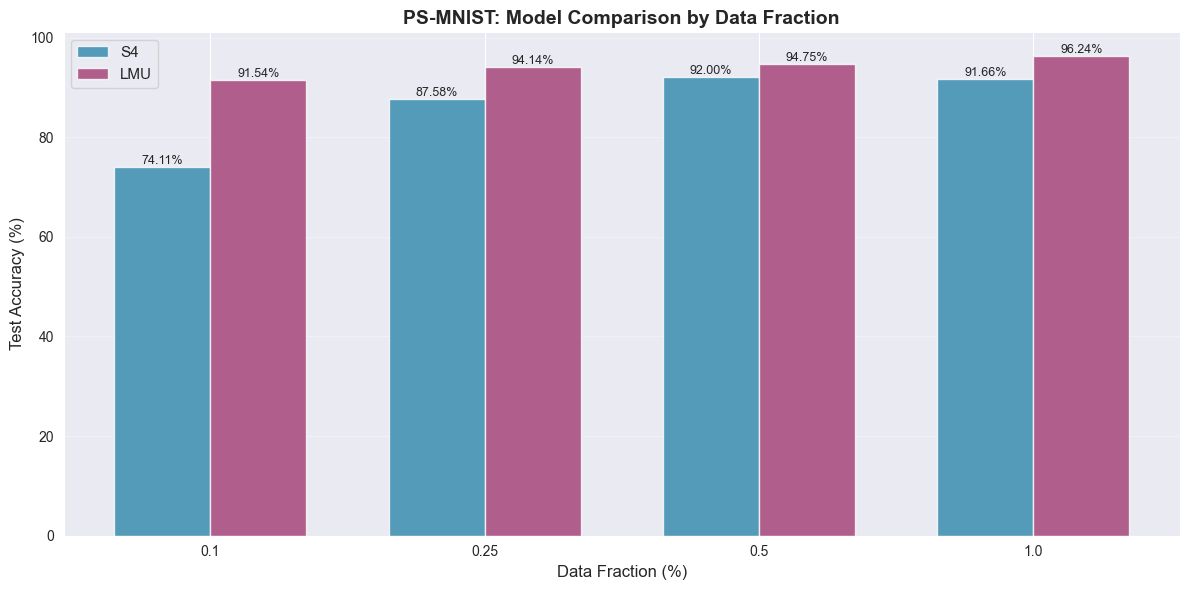

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(fractions))
width = 0.35

s4_data = df_results[df_results['model'] == 'S4'].sort_values('fraction')
lmu_data = df_results[df_results['model'] == 'LMU'].sort_values('fraction')

bars1 = ax.bar(x - width/2, s4_data['accuracy'] * 100, width,
               label='S4', alpha=0.8, color='#2E86AB')
bars2 = ax.bar(x + width/2, lmu_data['accuracy'] * 100, width,
               label='LMU', alpha=0.8, color='#A23B72')

ax.set_xlabel('Data Fraction (%)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('PS-MNIST: Model Comparison by Data Fraction', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fractions)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Data Efficiency Analysis

Analyze how efficiently each model learns with different amounts of data.


In [24]:
efficiency_data = []

for model in models:
    model_data = df_results[df_results['model'] == model.upper()].sort_values('fraction')
    accuracies = model_data['accuracy'].values

    for i in range(1, len(accuracies)):
        data_increase = fractions[i] - fractions[i-1]
        acc_increase = (accuracies[i] - accuracies[i-1]) * 100
        efficiency = acc_increase / data_increase

        efficiency_data.append({
            'model': model.upper(),
            'accuracy': accuracies[i],
            'from_fraction': fractions[i-1],
            'to_fraction': fractions[i],
            'accuracy_gain': acc_increase,
            'data_increase': data_increase,
            'efficiency': efficiency
        })

df_efficiency = pd.DataFrame(efficiency_data)
print("Data Efficiency (Accuracy Gain % per Data % Increase):")
df_efficiency


Data Efficiency (Accuracy Gain % per Data % Increase):


,model,accuracy,from_fraction,to_fraction,accuracy_gain,data_increase,efficiency
0,S4,0.8758,0.10,0.25,13.470000,0.15,89.800000
1,S4,0.9200,0.25,0.50,4.420000,0.25,17.680001
2,S4,0.9166,0.50,1.00,-0.340003,0.50,-0.680006
3,LMU,0.9414,0.10,0.25,2.599996,0.15,17.333309
4,LMU,0.9475,0.25,0.50,0.610000,0.25,2.440000
5,LMU,0.9624,0.50,1.00,1.490003,0.50,2.980006
